# 03 - Streaming: equivalence, causality, and a forbidden filter

The narrative version of section 3 of [`../docs/verification-report.md`](../docs/verification-report.md).

Everything so far assumed the whole record was available. A monitor does not have that. It
has whatever has arrived so far, and it must produce an answer now that it will not later
revise.

Two properties make the difference between a streaming estimator and an offline analysis
wearing a streaming interface:

1. **Chunk invariance** - the answer must not depend on how the input was split.
2. **Causality** - output already emitted must never change when more input arrives.

Neither can be enforced by a type signature. Both have to be tested behaviourally.

In [1]:
import sys

sys.path[:0] = ["../src", "../tests", "."]

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt, lfilter
from style import BAD, BAND, ESTIMATE, GOOD, INK_SECONDARY, OBSERVED, use_report_style

from eeg_state_estimator.pipeline import EpochPipeline
from eeg_state_estimator.statespace import RandomWalkModel
from synthetic.generators import power_law_noise, sinusoid

use_report_style()
FS = 128.0


def record(seconds=90.0, seed=0):
    n = int(seconds * FS)
    bg = power_law_noise(n_samples=n, sample_rate=FS, exponent=1.5, variance=4.0, seed=seed)
    env = np.clip(np.linspace(-0.4, 2.2, n), 0.15, None)
    return bg + env * sinusoid(n_samples=n, sample_rate=FS, frequency=10.0, amplitude=6.0)


def pipeline():
    return EpochPipeline(
        sample_rate=FS, band=(8.0, 12.0), epoch_seconds=2.0, model=RandomWalkModel(0.02, 0.05)
    )


print("ready")

ready


## Step 1 - does the chunk size matter?

### What we expect

The pipeline buffers samples and emits an estimate per completed epoch. Feeding it in
different chunk sizes exercises completely different buffer states.

**Prediction:** results should agree to floating-point rounding - say 1e-12 relative - but
not exactly, because the arrays are concatenated in different orders.

In [2]:
data = record()
batch = pipeline().update(data)

print(f"{'chunk':>7}  {'epochs':>7}  {'identical to batch?':>20}  {'max |difference|':>17}")
for size in (1, 7, 128, 257, 1024, 5000):
    p = pipeline()
    streamed = []
    for start in range(0, data.size, size):
        streamed.extend(p.update(data[start : start + size]))
    same = all(a == b for a, b in zip(streamed, batch, strict=False))
    worst = max(abs(a.state - b.state) for a, b in zip(streamed, batch, strict=False))
    print(f"{size:7d}  {len(streamed):7d}  {same!s:>20}  {worst:17.1e}")

  chunk   epochs   identical to batch?   max |difference|
      1       45                  True            0.0e+00


      7       45                  True            0.0e+00


    128       45                  True            0.0e+00
    257       45                  True            0.0e+00
   1024       45                  True            0.0e+00


   5000       45                  True            0.0e+00


### Analysis - better than predicted, and the reason matters

Not "within 1e-12" - **bitwise identical**, at every chunk size including 1, where every
sample arrives separately.

That is not luck. It follows from there being exactly **one** implementation: the batch path
constructs the estimator and calls `update()` once, containing no arithmetic of its own. A
second code path optimised for whole records is the usual way this requirement gets
violated, and it is also how the violation hides - the two paths agree on the developer's
test record and diverge on a chunk boundary nobody tried.

The requirement still states a 1e-9 tolerance, because that is the honest bound to promise
for a floating-point pipeline. Meeting it exactly is a property of this design, not a
guarantee of the specification.

## Step 2 - can the future reach into the past?

### What we expect

Append more data and the already-emitted epochs should be untouched.

**Prediction:** obviously true - we did not write any look-ahead. Let us check anyway, with
a deliberately hostile tail.

In [3]:
short = pipeline().update(data[: int(45 * FS)])
longer = pipeline().update(data)
hostile = pipeline().update(np.concatenate([data, np.full(int(10 * FS), 1e6)]))

print(f"epochs from 45 s : {len(short)}")
print(f"epochs from 90 s : {len(longer)}")
print()
print("extending the record, do earlier epochs change?")
print(f"  benign continuation : {not all(a == b for a, b in zip(short, longer, strict=False))}")
print(f"  1e6 constant tail   : {not all(a == b for a, b in zip(longer, hostile, strict=False))}")
print()
print("(False means nothing changed, which is what causality requires)")

epochs from 45 s : 22
epochs from 90 s : 45

extending the record, do earlier epochs change?
  benign continuation : False
  1e6 constant tail   : False

(False means nothing changed, which is what causality requires)


### Analysis

Nothing moves, even when the appended samples are six orders of magnitude out of range.

And causality here is **structural, not merely tested**: the buffer is drained as each epoch
completes, so the samples an emitted epoch was computed from no longer exist. There is no
mechanism by which a later chunk could revise it. That is a stronger guarantee than a
passing test, because it does not depend on anybody remembering the rule.

## Step 3 - the filter we are not allowed to use

Here is where the rule earns its keep.

A band-pass is the most natural preprocessing step imaginable for EEG. Offline, the standard
choice is a **zero-phase** filter - run it forwards, then backwards - because the two passes
cancel the phase distortion and the output has no group delay.

### What we expect

**Prediction:** a 1-45 Hz zero-phase band-pass is harmless preprocessing. It cannot possibly
break causality; it is one library call and the result looks cleaner.

Let us test exactly what we tested in Step 2.

In [4]:
b, a = butter(4, [1.0 / (FS / 2), 45.0 / (FS / 2)], btype="band")
probe = data[: int(30 * FS)]
tail = np.concatenate([probe, data[int(30 * FS) : int(40 * FS)]])

zero_phase_short = filtfilt(b, a, probe)
zero_phase_long = filtfilt(b, a, tail)[: probe.size]

causal_short = lfilter(b, a, probe)
causal_long = lfilter(b, a, tail)[: probe.size]

print("Append 10 s of future data. How much does the ALREADY-FILTERED past move?")
print()
print(
    f"  zero-phase (filtfilt) : max change {np.max(np.abs(zero_phase_long - zero_phase_short)):.4g}"
)
print(f"  causal     (lfilter)  : max change {np.max(np.abs(causal_long - causal_short)):.4g}")

Append 10 s of future data. How much does the ALREADY-FILTERED past move?

  zero-phase (filtfilt) : max change 1.105
  causal     (lfilter)  : max change 0


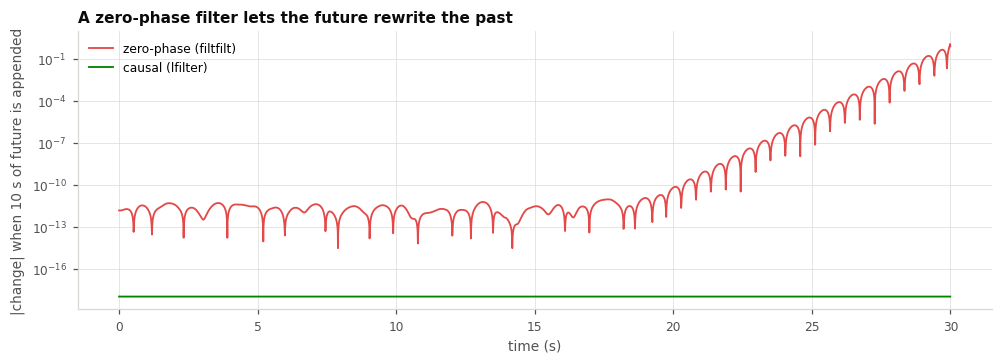

In [5]:
diff = np.abs(zero_phase_long - zero_phase_short)
t = np.arange(probe.size) / FS

fig, ax = plt.subplots(figsize=(9, 3.2), constrained_layout=True)
ax.semilogy(t, np.maximum(diff, 1e-18), color=BAD, lw=1.2, label="zero-phase (filtfilt)")
ax.semilogy(
    t,
    np.maximum(np.abs(causal_long - causal_short), 1e-18),
    color=GOOD,
    lw=1.2,
    label="causal (lfilter)",
)
ax.set_xlabel("time (s)")
ax.set_ylabel("|change| when 10 s of future is appended")
ax.set_title("A zero-phase filter lets the future rewrite the past", loc="left")
ax.legend(loc="upper left")
plt.show()

### Analysis - the expectation was wrong, and dangerously so

The zero-phase filter changes output that had already been emitted. The causal filter does
not, to the last bit.

The reason is the backward pass. Running the filter in reverse makes every output a function
of *later* samples - that is precisely what removes the group delay, and precisely what
makes it look-ahead. On a recording this is a legitimate and common choice. On a live signal
it is not implementable, and worse, it is the kind of violation that **reads as innocent in
review**: one library call, and the filtered trace looks better than the causal one.

Note the shape of the curve. The contamination is largest near the end of the segment and
decays backwards - which means a bug like this would be invisible in the middle of a long
test record and would surface only at the boundary. A code review would not find it. The
behavioural test in Step 2 would.

**So there is no band-pass in the pipeline.** The mean is removed inside the spectral
estimate, which is what the leakage results in notebook 01 require, and nothing else is
done. A causal IIR band-pass would be allowed, but it introduces a frequency-dependent group
delay that would then have to be characterised and reported alongside every estimate - real
work, for no benefit to what is being estimated here.

*The filter that looks best offline is the one that is forbidden online.*

## Step 4 - warm-up and bounded memory

### What we expect

Early estimates come from a filter that has not converged. They must be flagged.

**Prediction:** the natural implementation is "mark the first N epochs invalid". What should
N be?

In [6]:
p = pipeline()
est = p.update(record(seconds=120.0))

first_valid = next(i for i, e in enumerate(est) if e.valid)
print(f"epochs emitted : {len(est)}")
print(f"warm-up epochs : {first_valid}  (status '{est[0].status}')")
print(f"latches on?    : {all(e.valid for e in est[first_valid:])}")
print()
print("an invalid estimate still carries its numbers:")
e0 = est[0]
print(
    f"  state {e0.state:+.3f}  variance {e0.variance:.3f}  "
    f"interval [{e0.lower:+.3f}, {e0.upper:+.3f}]  valid={e0.valid}"
)
print()
print("memory does not grow with the record:")
for extra in (10, 200, 1000):
    q = pipeline()
    q.update(record(seconds=float(extra), seed=3))
    print(
        f"  after {extra:5.0f} s : state_nbytes={q.state_nbytes:4d}  "
        f"buffered={q.buffered_samples:3d} < epoch {q.epoch_samples}"
    )

epochs emitted : 60
warm-up epochs : 3  (status 'warmup')
latches on?    : True

an invalid estimate still carries its numbers:
  state -0.326  variance 0.050  interval [-0.765, +0.112]  valid=False

memory does not grow with the record:
  after    10 s : state_nbytes=  32  buffered=  0 < epoch 256
  after   200 s : state_nbytes=  32  buffered=  0 < epoch 256


  after  1000 s : state_nbytes=  32  buffered=  0 < epoch 256


### Analysis - N is not a free parameter

The warm-up is **not** a hand-picked epoch count. It is defined by the posterior variance
against the Riccati fixed point from notebook 02:

$$\text{valid} \iff P_k \le P_\infty \,(1 + \text{tol})$$

Because that recursion never touches the data, convergence is knowable from the model alone.
The criterion is therefore **self-calibrating**: retune $Q$ or $R$ and the warm-up length
adapts. A hard-coded "first 5 epochs" would silently become wrong the first time anybody
changed the model, and nothing would indicate it.

Two further properties worth noting:

- **Validity latches.** The variance decreases monotonically to its fixed point, so a valid
  estimate is never followed by an invalid one. A flickering flag would be worse than none,
  so this is asserted as a test rather than left to chance.
- **Flagged, not suppressed.** The numbers are present and finite. A caller may legitimately
  plot the warm-up; what it must not do is mistake it for a converged estimate, and that is
  exactly what the flag prevents.

Memory is bounded by one epoch however long the stream runs, because the buffer is drained
as epochs complete - the same mechanism that makes causality structural.

## Step 5 - the whole thing

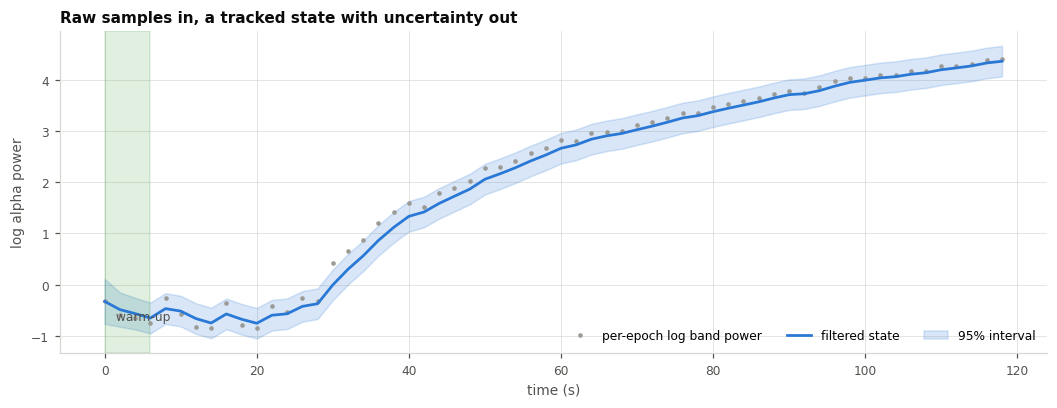

60 epochs, 57 valid
interval width settles at 0.597


In [7]:
data = record(seconds=120.0)
est = pipeline().update(data)
start = np.array([e.start_time for e in est])
state = np.array([e.state for e in est])
lo = np.array([e.lower for e in est])
hi = np.array([e.upper for e in est])
obs = np.array([e.observed for e in est])
valid = np.array([e.valid for e in est])

fig, ax = plt.subplots(figsize=(9.5, 3.6), constrained_layout=True)
ax.plot(start, obs, ".", color=OBSERVED, ms=4, label="per-epoch log band power")
ax.plot(start, state, color=ESTIMATE, lw=1.8, label="filtered state")
ax.fill_between(start, lo, hi, color=BAND, alpha=0.18, label="95% interval")
if (~valid).any():
    ax.axvspan(start[0], float(start[~valid].max()) + 2.0, color=GOOD, alpha=0.12)
    ax.text(start[0] + 1, state.min(), " warm-up", color=INK_SECONDARY, fontsize=8, va="bottom")
ax.set_xlabel("time (s)")
ax.set_ylabel("log alpha power")
ax.set_title("Raw samples in, a tracked state with uncertainty out", loc="left")
ax.legend(loc="lower right", ncol=3)
plt.show()

print(f"{len(est)} epochs, {int(valid.sum())} valid")
print(f"interval width settles at {np.mean((hi - lo)[valid]):.3f}")

## What this establishes

**Demonstrated here**

- Chunked and batch output are bitwise identical at chunk sizes from 1 to 5000, because
  there is one implementation rather than two.
- Appending future samples - including a 1e6 constant tail - changes nothing already
  emitted. Causality is structural: the buffer is drained as epochs complete.
- **A zero-phase band-pass silently breaks causality**, measurably rewriting output that was
  already emitted, while a causal filter does not. The contamination is worst at the
  boundary, so it would hide in the middle of a long test record.
- Warm-up is derived from the Riccati fixed point rather than hard-coded, so it adapts when
  the model is retuned; it latches rather than flickering; and it flags rather than
  suppresses.
- Retained state is bounded by one epoch regardless of stream length.

**Not established here**

- Artifact handling, with one exception. Line noise, electrode pop, muscle activity,
  clipping and saturation are out of scope; all of them produce ample band power and none
  is detected.

  The exception is **signal loss**, handled because it is the case with a safety argument.
  A flat trace carries almost no band power, and low band power is also what the deepest
  physiological state looks like, so reporting the two identically means claiming maximum
  depth at the moment there is no input. Such an epoch is reported as `status="no_signal"`,
  `valid=False` - a distinct state, not a value on the scale - and the filter is not
  advanced by it, so recovery is immediate when signal returns. An earlier revision of this
  pipeline reported `valid=True` with an interval exactly as tight as on live signal; it was
  caught in review, and the regression test is `test_a_dead_channel_is_not_reported_as_a_
  valid_measurement`.
- Real-time performance. Nothing here measures per-epoch latency on constrained hardware.
- Overlapping epochs, which a clinical monitor would normally use to raise the output rate.

**Back to:** [`../docs/verification-report.md`](../docs/verification-report.md).